# Практическая работа №4

**Цель работы:** изучить и сравнить методы построения деревьев решений Decision Tree и случайного леса Random Forest для решения задачи классификации. Применить Optuna для подбора гиперпараметров, сравнить с GridSearch.

**Задачи работы:**

1. Провести анализ и предобработку данных.
2. Реализовать базовую модель Decision Tree и оценить её качество.
3. Реализовать модель Random Forest и оценить её качество.
4. Сравнить точность и устойчивость моделей.
5. Использовать Optuna для подбора гиперпараметров и анализа влияния параметров на качество моделей.
6. Использовать GridSearchCV для подбора гиперпараметров и сравнить его результаты с Optuna.
7. Визуализировать дерево решений и структуру случайного леса (построить tree_plot).
8. Сделать выводы о наиболее подходящем методе для данного датасета.

**Используемые алгоритмы:**

1. **Decision Tree (дерево решений):** алгоритм, который последовательно делит пространство признаков на области, выбирая на каждом шаге наиболее информативный признак для разделения. Каждый узел дерева соответствует проверке условия, а листья итоговому классу. Метод простой в понимании, не требует нормализации данных, но склонен к переобучению и чувствителен к изменению данных. Основные параметры: criterion — критерий выбора лучшего разделения, max_depth — максимальная глубина дерева (ограничивает переобучение), min_samples_split — минимальное количество образцов для разделения узла, min_samples_leaf — минимальное количество объектов в листе.
2. **Random Forest (случайный лес):** ансамбль из множества деревьев решений.
Каждое дерево обучается на случайной подвыборке данных и случайном подмножестве признаков. Итоговое предсказание получается путём голосования (для классификации) или усреднения (для регрессии) результатов всех деревьев. Устойчив к переобучению, хорошо работает при большом количестве признаков, оценивает важность признаков, но менее интерпретируем по сравнению с одним деревом и требует больше вычислительных ресурсов. Основные параметры: n_estimators — количество деревьев в лесу, max_depth — глубина каждого дерева, max_features — число признаков, используемых при обучении одного дерева, min_samples_split, min_samples_leaf — параметры, аналогичные Decision Tree.
3. **Optuna:** библиотека для автоматического подбора гиперпараметров с использованием методов оптимизации на основе истории предыдущих экспериментов. Итеративно выбирает комбинации параметров, обучает модель и оценивает качество, стремясь минимизировать или максимизировать заданную метрику.
4. **GridSearchCV:** выполняет полный перебор заданных комбинаций гиперпараметров. Для каждой комбинации выполняется кросс-валидация, после чего выбирается набор параметров с наилучшим результатом по целевой метрике (например, Accuracy). Очень затратен по времени при большом числе параметров, невозможен при непрерывных пространствах параметров.

Датасет (из 1 работы): https://www.kaggle.com/datasets/jsphyg/weather-dataset-rattle-package/data

In [8]:
# Используемые библиотеки
!pip install optuna
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import optuna
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, make_scorer
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier

## 1. Загрузка и анализ данных

Ранее для данного датасета Rain in Australia была проведена полная предобработка данных: обработаны пропуски, удалены выбросы, категориальные признаки преобразованы с помощью One-Hot Encoding, удалены ненужные и сильно коррелированные признаки, дата преобразована в числовой формат. Данные разделены на обучающую (train), валидационную (valid) и тестовую (test) выборки.

In [9]:
# Загрузка обработанных ранее данных

!wget -q https://github.com/GusevaVarvara/Weather-dataset/raw/main/train_reduced.pkl
!wget -q https://github.com/GusevaVarvara/Weather-dataset/raw/main/val_reduced.pkl
!wget -q https://github.com/GusevaVarvara/Weather-dataset/raw/main/test_reduced.pkl

X_train, y_train = joblib.load("train_reduced.pkl")
X_val, y_val = joblib.load("val_reduced.pkl")
X_test, y_test = joblib.load("test_reduced.pkl")

In [ ]:
display(X_train.head())
display(y_train.head())

,Rainfall,Sunshine,WindGustSpeed,Humidity9am,Humidity3pm,Pressure9am,Cloud3pm,Temp3pm,RainToday,Location_Albany,...,Location_WaggaWagga,Location_Walpole,Location_Watsonia,Location_Williamtown,Location_Witchcliffe,Location_Wollongong,Location_Woomera,Year,Month,Day
10832,2.540517,-2.830020,0.769071,1.221947,0.511072,0.926395,1.028669,-0.780448,1,False,...,False,False,False,False,False,False,False,2011,6,13
64426,5.047411,0.173575,1.301877,0.272726,0.024543,-1.297080,0.719060,-0.083081,1,False,...,False,False,False,False,False,False,False,2017,1,17
61488,-0.279738,1.850000,0.236264,-1.098371,-0.559292,-0.911678,-0.828984,0.730514,0,False,...,False,False,False,False,False,False,False,2015,1,1
81810,-0.279738,-0.769414,0.084034,0.483664,1.484131,0.600286,1.028669,-1.448758,0,False,...,False,False,False,False,False,False,False,2013,6,16
70346,0.612137,-0.420159,-0.068197,1.274681,1.143560,0.363115,0.099843,-0.649691,1,False,...,False,False,False,False,False,False,False,2012,8,4


,RainTomorrow
10832,1
64426,1
61488,0
81810,1
70346,1


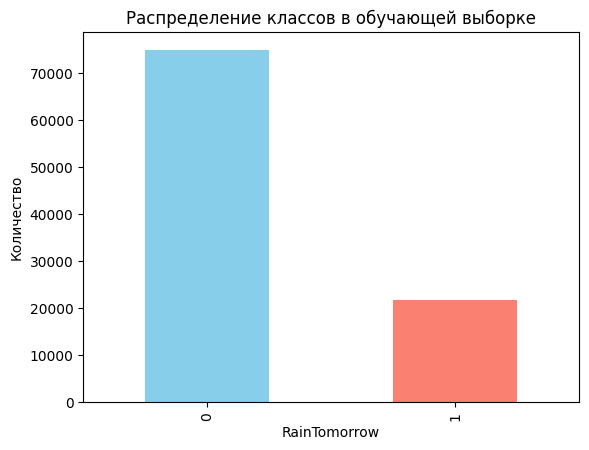

In [ ]:
# Распределение целевого признака
pd.Series(y_train).value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title("Распределение классов в обучающей выборке")
plt.xlabel("RainTomorrow")
plt.ylabel("Количество")
plt.show()

Для моделей на основе деревьев важно, чтобы данные были чистыми и не содержали выбросов и пропусков, что уже обеспечено на предыдущих этапах.

В данных наблюдается дисбаланс классов (в классе RainTomorrow = 1 объектов меньше), что может повлиять на метрики и требует учитывать не только Accuracy, но и F1-score, Recall.

## 2. Decision Tree

Обучим базовую модель DecisionTreeClassifier на ранее подготовленных данных. Оценим качество модели на валидационной и тестовой выборках и визуализируем дерево решений plot_tree для интерпретируемости.

Validation results (Decision Tree):
Accuracy: 0.7838
F1-score: 0.5271

Classification report (validation):
              precision    recall  f1-score   support

           0     0.8648    0.8550    0.8599     18754
           1     0.5171    0.5374    0.5271      5419

    accuracy                         0.7838     24173
   macro avg     0.6910    0.6962    0.6935     24173
weighted avg     0.7869    0.7838    0.7853     24173

Test results (Decision Tree):
Accuracy: 0.7852
F1-score: 0.5233

Classification report (test):
              precision    recall  f1-score   support

           0     0.8627    0.8600    0.8613     16548
           1     0.5206    0.5260    0.5233      4781

    accuracy                         0.7852     21329
   macro avg     0.6916    0.6930    0.6923     21329
weighted avg     0.7860    0.7852    0.7856     21329



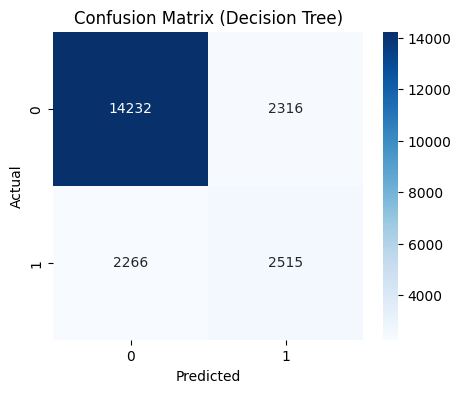

In [ ]:
# Обучение Decision Tree
dt = DecisionTreeClassifier(random_state=42, class_weight='balanced')  # balanced учитывает дисбаланс
dt.fit(X_train, y_train)

y_val_pred = dt.predict(X_val)
y_test_pred = dt.predict(X_test)

# Метрики на валидации
val_acc = accuracy_score(y_val, y_val_pred)
val_f1 = f1_score(y_val, y_val_pred)

print("Validation results (Decision Tree):")
print(f"Accuracy: {val_acc:.4f}")
print(f"F1-score: {val_f1:.4f}")
print("\nClassification report (validation):")
print(classification_report(y_val, y_val_pred, digits=4))

# Метрики на тесте
test_acc = accuracy_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)

print("Test results (Decision Tree):")
print(f"Accuracy: {test_acc:.4f}")
print(f"F1-score: {test_f1:.4f}")
print("\nClassification report (test):")
print(classification_report(y_test, y_test_pred, digits=4))

# Матрица ошибок
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Decision Tree)")
plt.show()


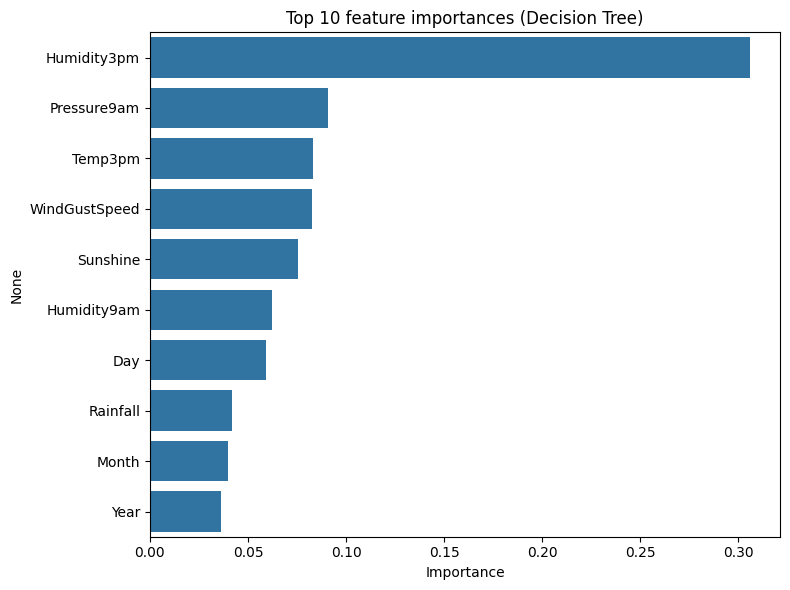

In [ ]:
# Важность признаков (топ-10)
feature_names = X_train.columns if hasattr(X_train, "columns") else [f"x{i}" for i in range(X_train.shape[1])]
importances = pd.Series(dt.feature_importances_, index=feature_names).sort_values(ascending=False)
top_n = 10
plt.figure(figsize=(8,6))
sns.barplot(x=importances.values[:top_n], y=importances.index[:top_n])
plt.title(f"Top {top_n} feature importances (Decision Tree)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

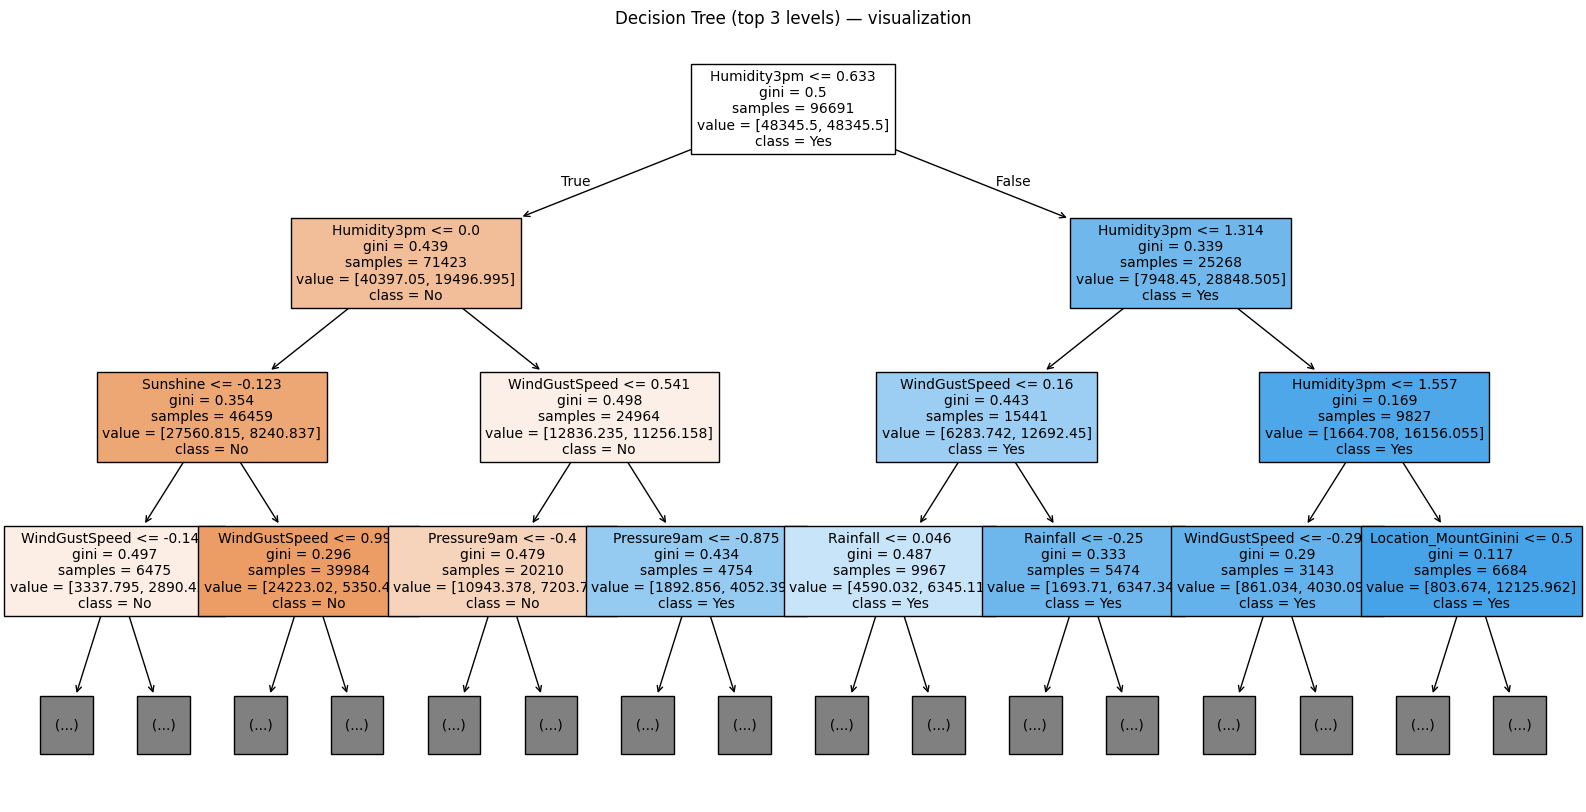

In [ ]:
# Визуализация дерева (ограничила глубину для читаемости)
plt.figure(figsize=(20,10))
plot_tree(dt, feature_names=feature_names, class_names=['No','Yes'], filled=True, max_depth=3, fontsize=10)
plt.title("Decision Tree (top 3 levels) — visualization")
plt.show()

Validation:

Accuracy = 0.7838

F1 (класс 1) = 0.5271

Test:

Accuracy = 0.7852

F1 (класс 1) = 0.5233


Модель правильно предсказывает около 78% случаев в среднем.
По матрице ошибок и F1-score для класса “дождь” = 0.52 видно, что модель улавливает лишь часть случаев дождя. Это связано с дисбалансом классов. Precision и Recall примерно равны, то есть модель одинаково часто допускает ложноположительные (предсказала дождь, но его не было) и ложноотрицательные (не предсказала дождь, хотя он был) ошибки.

Поскольку показатели на валидации и тесте близки, нет явного признака сильного переобучения, модель ведёт себя стабильно на новых данных и хорошо обобщает закономерности.

Самую высокую важность и влияние на предсказание имеет признак Humidity3pm, что логично, так как высокая влажность днём напрямую связана с вероятностью дождя. На визуализации дерева также видно, что первое разбиение происходит по этому признаку Humidity3pm ≤ 0.633. Модель в первую очередь проверяет, насколько влажно днём — если влажность меньше порога, вероятность дождя мала. На следующих уровнях, дерево уточняет прогноз с помощью комбинаций других признаков — влажность, давление, солнце, скорость порывов ветра и тд.

### Оптимизация гиперпараметров Decision Tree с помощью Optuna

Принцип работы:

1. Задаётся целевая функция (например, accuracy или F1-score на валидации).
2. Optuna случайно выбирает комбинации параметров, обучает модель и оценивает её.
3. Алгоритм анализирует, какие значения давали лучшие результаты, и адаптивно пробует новые.
4. По итогам итераций выбирается комбинация, которая дала максимальное (или минимальное) значение целевой метрики.

В датасете наблюдается дисбаланс классов и Accuracy мало информативна, так как простое предсказание «нет дождя» даст высокое значение точности, но не выявит редкий класс. Поэтому при оптимизации гиперпараметров с помощью Optuna используем F1-score для класса «дождь».



In [ ]:
# Функция, которую Optuna будет оптимизировать
def objective(trial):
    # Диапазоны для гиперпараметров
    max_depth = trial.suggest_int('max_depth', 2, 30)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 20)
    criterion = trial.suggest_categorical('criterion', ['gini', 'entropy', 'log_loss'])

    # Создаём модель
    model = DecisionTreeClassifier(
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        criterion=criterion,
        random_state=42)

    # Оцениваем качество с помощью кросс-валидации
    score = cross_val_score(model, X_train, y_train, cv=3, scoring='f1').mean()
    return score

# Создаём и запускаем исследование
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30, show_progress_bar=True)

print("Best parameters:", study.best_params)
print("Best F1-score:", study.best_value)


[I 2025-10-18 12:45:51,683] A new study created in memory with name: no-name-070ef606-feff-4692-ad47-7502c9694940


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2025-10-18 12:45:55,317] Trial 0 finished with value: 0.5622077179192676 and parameters: {'max_depth': 27, 'min_samples_split': 20, 'min_samples_leaf': 17, 'criterion': 'gini'}. Best is trial 0 with value: 0.5622077179192676.
[I 2025-10-18 12:45:55,934] Trial 1 finished with value: 0.5241971367704313 and parameters: {'max_depth': 3, 'min_samples_split': 4, 'min_samples_leaf': 6, 'criterion': 'entropy'}. Best is trial 0 with value: 0.5622077179192676.
[I 2025-10-18 12:45:57,261] Trial 2 finished with value: 0.5492710146532892 and parameters: {'max_depth': 7, 'min_samples_split': 8, 'min_samples_leaf': 7, 'criterion': 'gini'}. Best is trial 0 with value: 0.5622077179192676.
[I 2025-10-18 12:45:58,406] Trial 3 finished with value: 0.543479021918531 and parameters: {'max_depth': 6, 'min_samples_split': 5, 'min_samples_leaf': 16, 'criterion': 'gini'}. Best is trial 0 with value: 0.5622077179192676.
[I 2025-10-18 12:45:58,869] Trial 4 finished with value: 0.3951706178401719 and parameters

Применим найденные параметры.

In [ ]:
# Обучаем финальную модель с лучшими параметрами
best_params = study.best_params
dt_optuna = DecisionTreeClassifier(**best_params, random_state=42)
dt_optuna.fit(X_train, y_train)

y_val_pred_opt = dt_optuna.predict(X_val)
y_test_pred_opt = dt_optuna.predict(X_test)

# Метрики на валидации
val_acc = accuracy_score(y_val, y_val_pred_opt)
val_f1 = f1_score(y_val, y_val_pred_opt)

print("Validation results (Decision Tree):")
print(f"Accuracy: {val_acc:.4f}")
print(f"F1-score: {val_f1:.4f}")
print("\nClassification report (validation):")
print(classification_report(y_val, y_val_pred_opt, digits=4))

# Метрики на тесте
test_acc = accuracy_score(y_test, y_test_pred_opt)
test_f1 = f1_score(y_test, y_test_pred_opt)

print("Test results (Decision Tree):")
print(f"Accuracy: {test_acc:.4f}")
print(f"F1-score: {test_f1:.4f}")
print("\nClassification report (test):")
print(classification_report(y_test, y_test_pred_opt, digits=4))


Validation results (Decision Tree):
Accuracy: 0.8274
F1-score: 0.5657

Classification report (validation):
              precision    recall  f1-score   support

           0     0.8648    0.9215    0.8923     18754
           1     0.6487    0.5016    0.5657      5419

    accuracy                         0.8274     24173
   macro avg     0.7568    0.7115    0.7290     24173
weighted avg     0.8164    0.8274    0.8191     24173

Test results (Decision Tree):
Accuracy: 0.8317
F1-score: 0.5757

Classification report (test):
              precision    recall  f1-score   support

           0     0.8671    0.9248    0.8950     16548
           1     0.6619    0.5093    0.5757      4781

    accuracy                         0.8317     21329
   macro avg     0.7645    0.7171    0.7353     21329
weighted avg     0.8211    0.8317    0.8234     21329



F1-score для класса 1 вырос с 0.523 до 0.576 на тесте. Accuracy также выросло, с 0.785 до 0.832, что также говорит о более качественном разделении классов. Модель стала лучше находить редкий класс, сохраняя приемлемую точность по доминирующему классу.

Значения Accuracy и F1-score на валидации и тесте близки. Модель не переобучилась, а оптимизация с помощью Optuna помогла повысить качество на новых данных.

Эта оптимизация делает Decision Tree с Optuna предпочтительнее, чем базовое дерево, для задачи прогнозирования дождя.

### GridSearch

In [ ]:
# Составляем сетку гиперпараметров
param_grid = {
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 10, 20],
    'min_samples_leaf': [1, 10, 20],
    'criterion': ['gini', 'entropy', 'log_loss']
}

# F1-score для класса "дождь"
f1_scorer = make_scorer(f1_score, pos_label=1)

# Создаём GridSearch
grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    scoring=f1_scorer,
    cv=3,
    n_jobs=-1,
    verbose=1
)

# Запускаем поиск
grid_search.fit(X_train, y_train)

print("Best parameters (GridSearch):", grid_search.best_params_)
print("Best F1-score (GridSearch):", grid_search.best_score_)

Fitting 3 folds for each of 108 candidates, totalling 324 fits
Best parameters (GridSearch): {'criterion': 'entropy', 'max_depth': 30, 'min_samples_leaf': 20, 'min_samples_split': 2}
Best F1-score (GridSearch): 0.568621911347444


Применим найденные параметры.

In [ ]:
# Лучшие параметры из GridSearch
best_params_gs = {
    'criterion': 'entropy',
    'max_depth': 30,
    'min_samples_leaf': 20,
    'min_samples_split': 2,
    'random_state': 42}

# Обучаем финальную модель с этими параметрами
dt_gs = DecisionTreeClassifier(**best_params_gs)
dt_gs.fit(X_train, y_train)

y_val_pred_gs = dt_gs.predict(X_val)
y_test_pred_gs = dt_gs.predict(X_test)

# Метрики на валидации
val_acc = accuracy_score(y_val, y_val_pred_gs)
val_f1 = f1_score(y_val, y_val_pred_gs, pos_label=1)
print("Validation results (Decision Tree - GridSearch):")
print(f"Accuracy: {val_acc:.4f}")
print(f"F1-score: {val_f1:.4f}")
print("\nClassification report (validation):")
print(classification_report(y_val, y_val_pred_gs, digits=4))

# Метрики на тесте
test_acc = accuracy_score(y_test, y_test_pred_gs)
test_f1 = f1_score(y_test, y_test_pred_gs, pos_label=1)
print("Test results (Decision Tree - GridSearch):")
print(f"Accuracy: {test_acc:.4f}")
print(f"F1-score: {test_f1:.4f}")
print("\nClassification report (test):")
print(classification_report(y_test, y_test_pred_gs, digits=4))

Validation results (Decision Tree - GridSearch):
Accuracy: 0.8274
F1-score: 0.5656

Classification report (validation):
              precision    recall  f1-score   support

           0     0.8648    0.9217    0.8923     18754
           1     0.6490    0.5012    0.5656      5419

    accuracy                         0.8274     24173
   macro avg     0.7569    0.7114    0.7290     24173
weighted avg     0.8164    0.8274    0.8191     24173

Test results (Decision Tree - GridSearch):
Accuracy: 0.8318
F1-score: 0.5763

Classification report (test):
              precision    recall  f1-score   support

           0     0.8673    0.9248    0.8951     16548
           1     0.6621    0.5101    0.5763      4781

    accuracy                         0.8318     21329
   macro avg     0.7647    0.7175    0.7357     21329
weighted avg     0.8213    0.8318    0.8236     21329



Сравним результаты оптимизации Decision Tree с помощью Optuna и GridSearch.

Accuracy почти одинаковая для обоих методов, около 82–83%. Это показывает, что оба способа подбора гиперпараметров дают стабильные модели.

F1-score для класса «дождь» также очень близки (0.565–0.576). Разница минимальна, что говорит о том, что ни один метод не даёт значительного преимущества по качеству выявления редкого класса.

Optuna хорошо подходит для больших наборов гиперпараметров и нестандартных критериев. GridSearch прост в реализации, но медленный при большом числе комбинаций.

Для данной задачи и выбранной сетки параметров результаты Optuna и GridSearch практически идентичны, но Optuna выигрывает по скорости вычислений, поэтому она здесь предпочтительнее.

## 3. Random Forest

Обучим модель Random Forest, обычно он более устойчив к шуму и дисбалансу классов, чем одно дерево.

Validation Accuracy: 0.8513630910520001
Validation F1-score: 0.5995765072996768
Classification report (validation):
               precision    recall  f1-score   support

           0       0.87      0.95      0.91     18754
           1       0.76      0.50      0.60      5419

    accuracy                           0.85     24173
   macro avg       0.81      0.73      0.75     24173
weighted avg       0.84      0.85      0.84     24173

Test Accuracy: 0.8566271273852502
Test F1-score: 0.6111393692777213
Classification report (test):
               precision    recall  f1-score   support

           0       0.87      0.96      0.91     16548
           1       0.78      0.50      0.61      4781

    accuracy                           0.86     21329
   macro avg       0.82      0.73      0.76     21329
weighted avg       0.85      0.86      0.84     21329



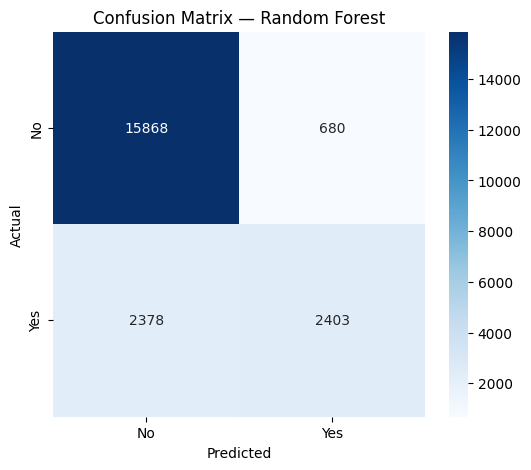

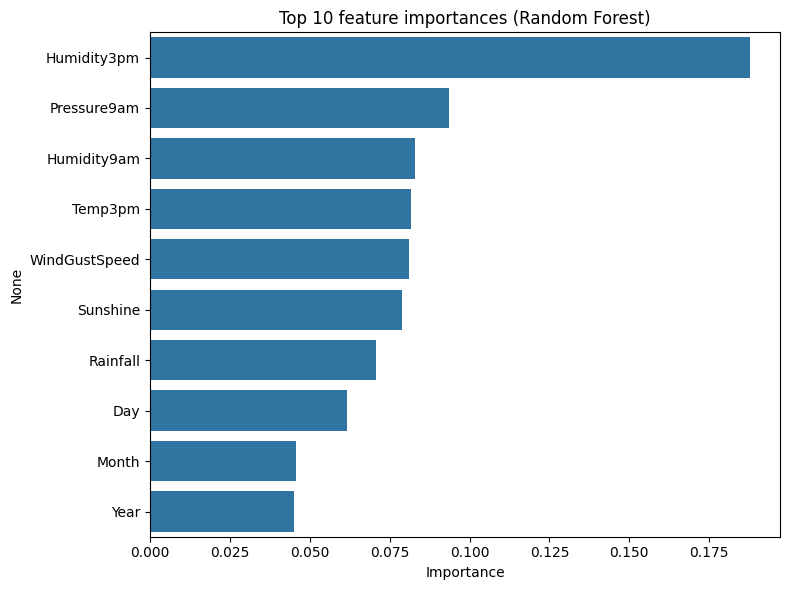

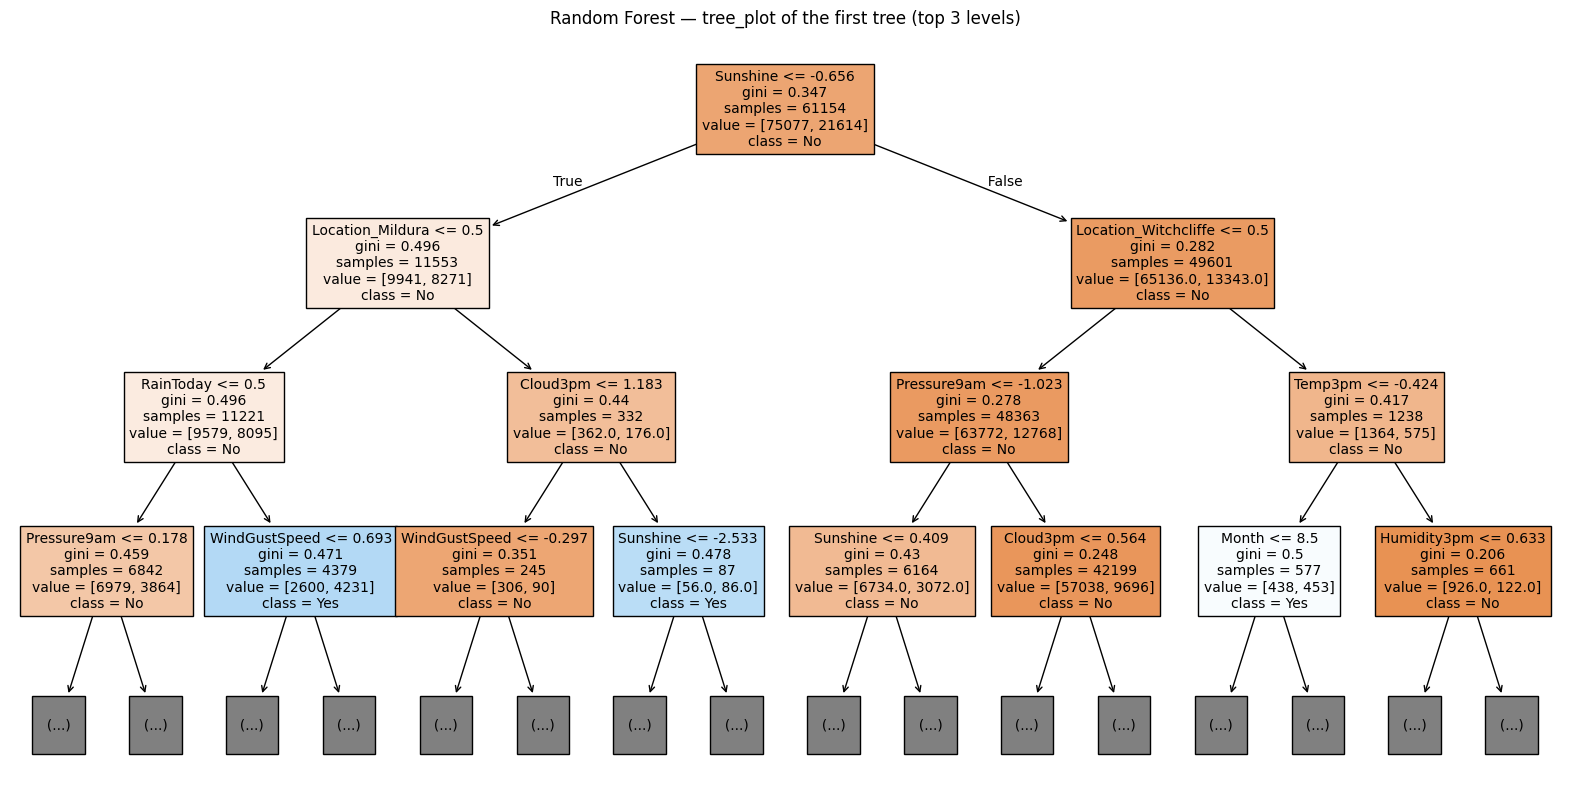

In [ ]:
# Инициализация Random Forest
rf = RandomForestClassifier(
    n_estimators=100,        # число деревьев
    max_depth=None,          # без ограничения глубины
    random_state=42,
    n_jobs=-1)

# Обучение
rf.fit(X_train, y_train)

y_val_pred = rf.predict(X_val)
y_test_pred = rf.predict(X_test)

# Метрики
print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))
print("Validation F1-score:", f1_score(y_val, y_val_pred, pos_label=1))
print("Classification report (validation):\n", classification_report(y_val, y_val_pred))

print("Test Accuracy:", accuracy_score(y_test, y_test_pred))
print("Test F1-score:", f1_score(y_test, y_test_pred, pos_label=1))
print("Classification report (test):\n", classification_report(y_test, y_test_pred))

# Матрица ошибок
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Random Forest")
plt.show()

# Важность признаков (топ-10)
feature_names = X_train.columns if hasattr(X_train, "columns") else [f"x{i}" for i in range(X_train.shape[1])]
importances = pd.Series(rf.feature_importances_, index=feature_names).sort_values(ascending=False)
top_n = 10
plt.figure(figsize=(8,6))
sns.barplot(x=importances.values[:top_n], y=importances.index[:top_n])
plt.title(f"Top {top_n} feature importances (Random Forest)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

# Визуализация дерева (одно дерево из леса)
plt.figure(figsize=(20,10))
plot_tree(rf.estimators_[0], feature_names=feature_names, class_names=['No','Yes'], filled=True, max_depth=3, fontsize=10)
plt.title("Random Forest — tree_plot of the first tree (top 3 levels)")
plt.show()

Validation set:

Accuracy = 0.851

F1-score (класс 1) = 0.60

Test set:

Accuracy = 0.857

F1-score (класс 1) = 0.61

Модель Random Forest работает лучше, чем отдельное дерево: точность и F1-score выросли по сравнению с Decision Tree. Дисбаланс классов всё ещё влияет: класс «дождь» имеет более низкий recall, что отражает сложность правильно предсказывать редкий класс. Precision для класса «дождь» повысился, что говорит о том, что среди предсказанных дождей теперь меньше ложноположительных случаев. Accuracy выше, чем у дерева: Random Forest усредняет предсказания многих деревьев и уменьшает переобучение.

Для одного из деревьев первый узел разделения оказался по Sunshine <= -0.656.

Можно также попробовать построить одно полное дерево, чтобы увидеть все разбиения, но оно будет очень большим.

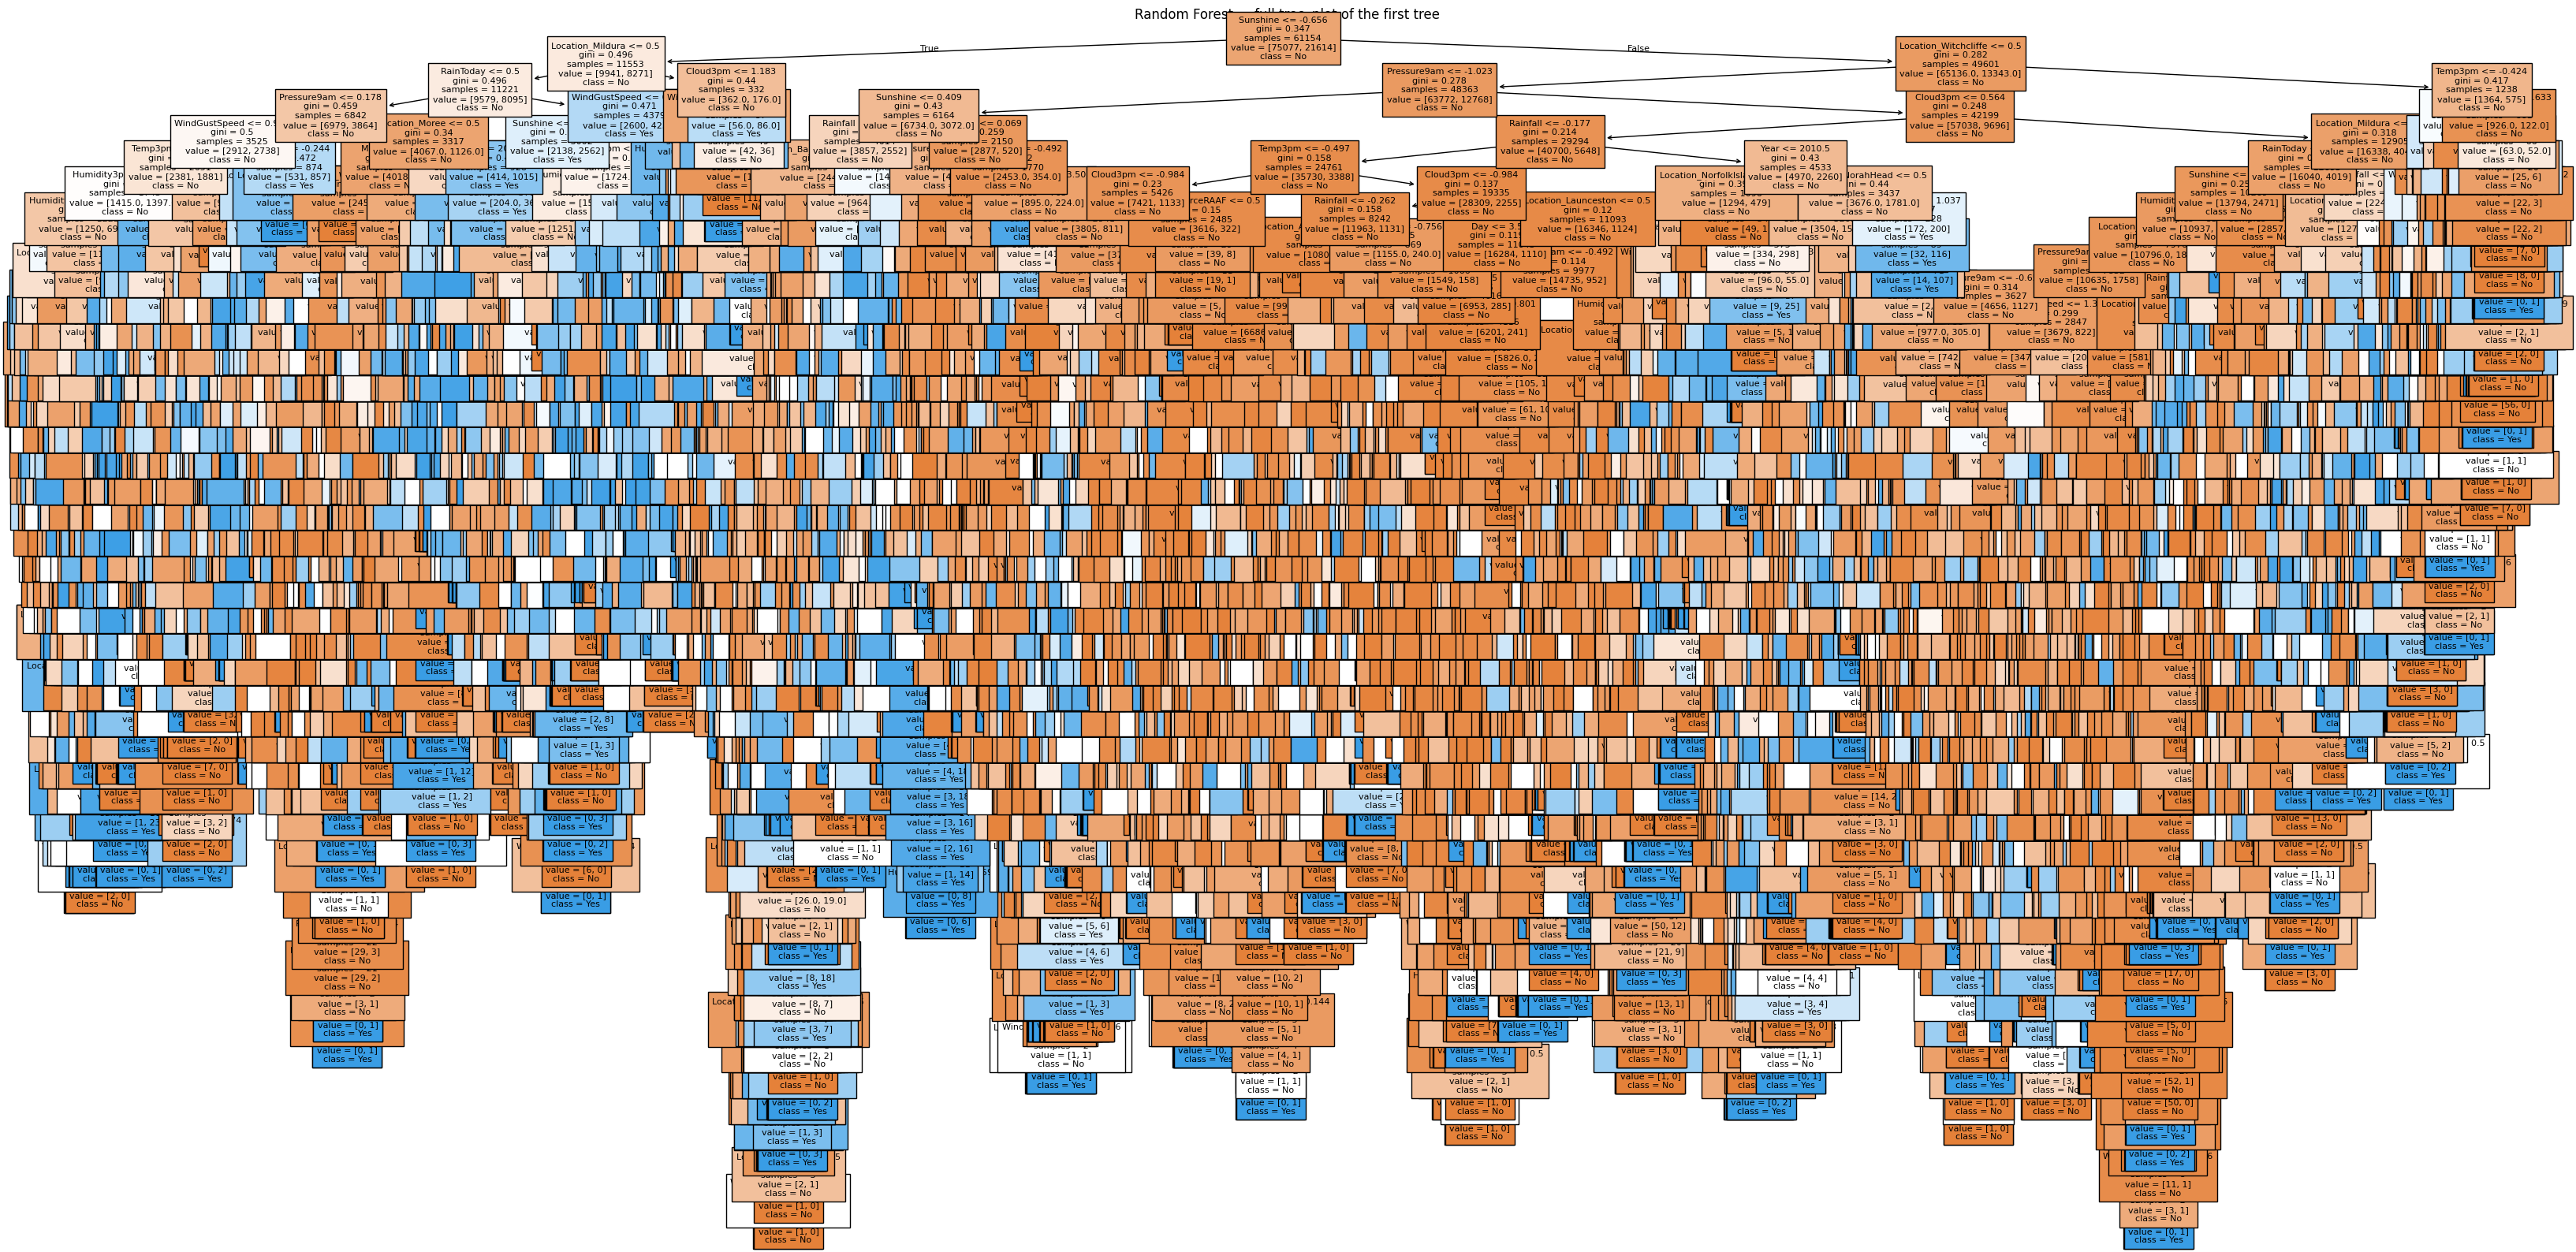

In [ ]:
# Первое дерево в лесу
plt.figure(figsize=(40,20))
plot_tree(
    rf.estimators_[0],
    feature_names=feature_names,
    class_names=['No','Yes'],
    filled=True,
    fontsize=8
)
plt.title("Random Forest — full tree_plot of the first tree")
plt.show()


### Optuna

Optuna будет автоматически подбирать лучшие гиперпараметры для Random Forest, будем оптимизировать также F1-score для класса «дождь», так как он менее представленный. Рассматриваем основные гиперпараметры: n_estimators, max_depth, min_samples_split, min_samples_leaf, max_features, criterion.

In [ ]:
# Функция для оптимизации
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 300),
        "max_depth": trial.suggest_int("max_depth", 5, 50),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 50),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 50),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
        "criterion": trial.suggest_categorical("criterion", ["gini", "entropy", "log_loss"]),
        "random_state": 42,
        "n_jobs": -1
    }

    rf = RandomForestClassifier(**params)
    rf.fit(X_train, y_train)
    y_val_pred = rf.predict(X_val)

    # F1-score для класса "дождь"
    f1 = f1_score(y_val, y_val_pred, pos_label=1)
    return f1

# Запуск оптимизации
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30)

print("Best parameters:", study.best_params)
print("Best F1-score:", study.best_value)

[I 2025-10-18 13:50:33,083] A new study created in memory with name: no-name-9de5f536-65d8-4205-9330-41412722ed08
[I 2025-10-18 13:50:59,662] Trial 0 finished with value: 0.5263157894736842 and parameters: {'n_estimators': 219, 'max_depth': 14, 'min_samples_split': 8, 'min_samples_leaf': 28, 'max_features': 'log2', 'criterion': 'gini'}. Best is trial 0 with value: 0.5263157894736842.
[I 2025-10-18 13:51:09,588] Trial 1 finished with value: 0.4345844504021448 and parameters: {'n_estimators': 130, 'max_depth': 6, 'min_samples_split': 50, 'min_samples_leaf': 30, 'max_features': 'sqrt', 'criterion': 'entropy'}. Best is trial 0 with value: 0.5263157894736842.
[I 2025-10-18 13:51:32,171] Trial 2 finished with value: 0.5662847790507365 and parameters: {'n_estimators': 138, 'max_depth': 15, 'min_samples_split': 28, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'criterion': 'entropy'}. Best is trial 2 with value: 0.5662847790507365.
[I 2025-10-18 13:51:45,824] Trial 3 finished with value: 0.48

Best parameters: {'n_estimators': 76, 'max_depth': 34, 'min_samples_split': 12, 'min_samples_leaf': 6, 'max_features': None, 'criterion': 'entropy'}
Best F1-score: 0.6056168724729538


Применим найденные параметры.

In [ ]:
# Применяем лучшие параметры
best_params = study.best_params
rf_optuna = RandomForestClassifier(**best_params)
rf_optuna.fit(X_train, y_train)

# Метрики на валидации
y_val_pred_optuna = rf_optuna.predict(X_val)
print("Validation F1-score (Optuna):", f1_score(y_val, y_val_pred_optuna, pos_label=1))
print(classification_report(y_val, y_val_pred_optuna, digits=4))

# Метрики на тесте
y_test_pred_optuna = rf_optuna.predict(X_test)
print("Test F1-score (Optuna):", f1_score(y_test, y_test_pred_optuna, pos_label=1))
print(classification_report(y_test, y_test_pred_optuna, digits=4))

Validation F1-score (Optuna): 0.603056768558952
              precision    recall  f1-score   support

           0     0.8700    0.9478    0.9072     18754
           1     0.7383    0.5097    0.6031      5419

    accuracy                         0.8496     24173
   macro avg     0.8041    0.7287    0.7551     24173
weighted avg     0.8404    0.8496    0.8390     24173

Test F1-score (Optuna): 0.6094667166229549
              precision    recall  f1-score   support

           0     0.8707    0.9525    0.9098     16548
           1     0.7564    0.5104    0.6095      4781

    accuracy                         0.8534     21329
   macro avg     0.8135    0.7314    0.7596     21329
weighted avg     0.8451    0.8534    0.8424     21329



F1-score практически не изменился. Recall немного вырос, модель стала чуть лучше замечать дождливые дни, но чуть больше ошибается ложноположительно (снижение precision). Accuracy не изменился, оба варианта дают примерно одинаковую точность (около 85%).

Optuna не дала заметного выигрыша — улучшения минимальные, в пределах шума, что говорит о том, что базовые гиперпараметры уже были близки к оптимальным, и Optuna не смогла заметно улучшить баланс между precision и recall. Поиск гиперпараметров в данном случае был очень времезатратный и не дал важных улучшений.

### GridSearch

In [11]:
# Сетка гиперпараметров
param_grid = {
    "n_estimators": [100],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 10],
    "min_samples_leaf": [1, 5],
    "max_features": ["sqrt"],
}

# Инициализация GridSearch
rf = RandomForestClassifier(random_state=42, n_jobs=-1)
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring="f1",
    cv=2,
    verbose=0
)

# Запуск поиска
grid_search.fit(X_train, y_train)

print("Best parameters (GridSearch RF):", grid_search.best_params_)
print("Best F1-score (GridSearch RF):", grid_search.best_score_)

Best parameters (GridSearch RF): {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best F1-score (GridSearch RF): 0.59108743666987


Применим найденные параметры.

In [12]:
# Применяем лучшие параметры
best_params_rf = grid_search.best_params_
rf_gs = RandomForestClassifier(**best_params_rf, random_state=42, n_jobs=-1)
rf_gs.fit(X_train, y_train)

y_val_pred_gs = rf_gs.predict(X_val)
y_test_pred_gs = rf_gs.predict(X_test)

# Метрики на валидации
print("Validation Accuracy (GridSearch RF):", accuracy_score(y_val, y_val_pred_gs))
print("Validation F1-score (GridSearch RF):", f1_score(y_val, y_val_pred_gs, pos_label=1))
print("\nClassification report (validation):\n", classification_report(y_val, y_val_pred_gs, digits=4))

# Метрики на тесте
print("Test Accuracy (GridSearch RF):", accuracy_score(y_test, y_test_pred_gs))
print("Test F1-score (GridSearch RF):", f1_score(y_test, y_test_pred_gs, pos_label=1))
print("\nClassification report (test):\n", classification_report(y_test, y_test_pred_gs, digits=4))

Validation Accuracy (GridSearch RF): 0.8513630910520001
Validation F1-score (GridSearch RF): 0.5995765072996768

Classification report (validation):
               precision    recall  f1-score   support

           0     0.8676    0.9539    0.9087     18754
           1     0.7569    0.4964    0.5996      5419

    accuracy                         0.8514     24173
   macro avg     0.8123    0.7252    0.7542     24173
weighted avg     0.8428    0.8514    0.8394     24173

Test Accuracy (GridSearch RF): 0.8566271273852502
Test F1-score (GridSearch RF): 0.6111393692777213

Classification report (test):
               precision    recall  f1-score   support

           0     0.8697    0.9589    0.9121     16548
           1     0.7794    0.5026    0.6111      4781

    accuracy                         0.8566     21329
   macro avg     0.8246    0.7308    0.7616     21329
weighted avg     0.8494    0.8566    0.8446     21329



Метрики практически совпадают с результатами базовой модели и оптимизации с Optuna — различия не превышают 0.01–0.02 по F1. Модель по-прежнему уверенно классифицирует случаи без дождя (класс 0) с точностью около 95%,
а вот для дождя (класс 1) F1 остаётся умеренным (около 0.6), что объясняется дисбалансом классов. Общая точность около 85% подтверждает, что случайный лес — мощная и устойчивая модель для этих данных.

Изначально GridSearchCV был настроен на более широкий перебор комбинаций параметров, но расчет занимал слишком большое количество времени, поэтому, чтобы сохранить баланс между скоростью и качеством, сетка была сокращена и уменьшено число проверяемых комбинаций. В результате GridSearch стал работать в десятки раз быстрее, сохранив качество на уровне Optuna.

Результат GridSearch также практически совпадает с Optuna, но тратит значительно больше времени, что говорит о преимуществе Optuna на этих данных, но в целом оптимизация здесь не улучшила результаты.

## Вывод

В ходе работы были проведены эксперименты по обучению и сравнению нескольких моделей классификации для задачи бинарного предсказания. Были рассмотрены две базовые модели — Decision Tree и Random Forest, а также методы оптимизации их гиперпараметров с использованием Optuna и GridSearchCV.

**Decision Tree:** Базовая модель показала удовлетворительное качество, однако низкий F1-score из-за влияния дисбаланса классов. Оптимизация гиперпараметров с помощью Optuna и GridSearchCV дала незначительное, но стабильное улучшение метрик, в частности F1-score для тестовой выборки вырос до = 0.57. Основное ограничение метода — высокая чувствительность к выбору глубины дерева и порогов разбиения, что делает модель менее обобщающей.

**Random Forest:** Использование ансамбля деревьев позволило существенно повысить устойчивость модели и общие показатели качества, однако потребовало гораздо больше времени. Базовая модель дала F1-score = 0.61 на тесте, что заметно выше, чем у одиночного дерева. Оптимизация гиперпараметров здесь практически не улучшила результаты, что указывает на устойчивость случайного леса к изменению параметров.

**Методы Optuna и GridSearchCV** продемонстрировали близкие результаты, однако Optuna оказалась существенно быстрее за счёт эвристического перебора параметров.

Итог: модель Random Forest показала наилучшее соотношение качества и стабильности. Методы оптимизации подтвердили, что она устойчива к подбору гиперпараметров, а значит, является надёжным выбором для решения поставленной задачи.